# ISM analysis of LMNA cCREs

This notebook does not run in silico mutagenesis. It loads per-cCRE AlphaGenome ISM CSVs from `lmna_ism_out/`, visualizes one predicted regulatory region, then keeps the top 1% of variants per cCRE for a single scorer (`RNA_SEQ, RECOMMENDED`). Scores were computed with 1 Mb sequence context.


# Setup

## Imports

Load AlphaGenome data, interpretation, and visualization modules, plus pandas, numpy, and plotting libraries. API keys are read from `.env` as numbered `AG_API_KEY_*` variables.


In [ ]:
from alphagenome_research.model import dna_model
from alphagenome import colab_utils
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript
from alphagenome.data import ontology
from alphagenome.interpretation import ism
from alphagenome.models import dna_client
from alphagenome.models import variant_scorers
from alphagenome.visualization import plot_components

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from pysam import VariantFile
from io import StringIO
from tqdm import tqdm
import os
import gc
from dotenv import load_dotenv
import seaborn as sns

# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE']='true'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.9' # pre allocates XX% of total GPU instead of the default 75%

pd.set_option('display.max_columns', None)
load_dotenv(dotenv_path=".env")
API_KEYS = [v for _, v in sorted(
    ((k, os.environ[k].strip()) for k in os.environ
     if k.startswith("AG_API_KEY_") and k.removeprefix("AG_API_KEY_").isdigit()),
    key=lambda kv: int(kv[0].removeprefix("AG_API_KEY_")),
) if v]


## Paths and constants

LMNA coordinates, reference annotation paths, requested output modalities, and the predicted cCRE BED used as ISM windows. `ccre_bed_path` points at predicted central-LV cCRE-like regions.


In [2]:
LMNA_START = 156_082_572
LMNA_END = 156_140_081
gene_symbol = "LMNA"
LMNA_INTERVAL = genome.Interval('chr1', 156_082_572, 156_140_081)


BASE_PATH = '/users/PAS2905/coraalbers/'
AG_DATA_PATH = '/users/PAS2905/coraalbers/ag/ag_data/'

HG38_FASTA_PATH = '/users/PAS2905/coraalbers/ag/hg38.fa'
HG38_GTF_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.annotation.gtf.gz.feather'
HG38_SPLICE_START_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.splice_sites_starts.feather'
HG38_SPLICE_END_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.splice_sites_ends.feather'
CALIBRATION_PATH = f'{AG_DATA_PATH}calibration_scores.pb'

gtf = pd.read_feather( 'https://storage.googleapis.com/alphagenome/reference/gencode/' 'hg38/gencode.v46.annotation.gtf.gz.feather' )

output_modalities = ['atac',	
    'cage',	
    'chip_histone',	
    'chip_tf',	
    'contact_maps',	
    'dnase',	
    'procap',	
    'rna_seq',	
    'splice_junctions',	
    'splice_site_usage',	
    'splice_sites']

requested_outputs = {dna_client.OutputType.ATAC,
        dna_client.OutputType.CAGE,
        dna_client.OutputType.DNASE,
        dna_client.OutputType.PROCAP,
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.SPLICE_SITES,
        dna_client.OutputType.SPLICE_SITE_USAGE,
        dna_client.OutputType.SPLICE_JUNCTIONS,
        dna_client.OutputType.CONTACT_MAPS,
        dna_client.OutputType.CHIP_HISTONE,
        dna_client.OutputType.CHIP_TF}

ccre_bed_path = f'{BASE_PATH}ag/variant-effects/osc/data_sync/predicted_ccre_like_regions_central_LV_128res.bed'

## Load model

Create AlphaGenome API client with `dna_client.create`.

In [3]:
# all_folds_model = dna_model.create_from_huggingface( 'all_folds',
#     organism_settings={ 
#         dna_model.Organism.HOMO_SAPIENS: dna_model.OrganismSettings( 
#             fasta_path=HG38_FASTA_PATH, 
#             gtf_feather_path=HG38_GTF_PATH, 
#             splice_site_starts_feather_path=HG38_SPLICE_START_PATH, 
#             splice_site_ends_feather_path=HG38_SPLICE_END_PATH, 
#             calibration_path=CALIBRATION_PATH,
#         ), dna_model.Organism.MUS_MUSCULUS: dna_model.OrganismSettings() } 
# )

model = dna_client.create(API_KEYS[5])


print('all folds model initialized!')

all folds model initialized!


# Load predicted cCREs

Read the BED of predicted central-LV cCRE-like regions. Each row is one ISM window (`chrom`, `start`, `end`, `name`). `ccre_df` is used both to locate per-cCRE CSVs and to tag variants with the `ccre_id` they are located within.


In [ ]:
ccre_df = pd.read_csv(ccre_bed_path, sep='\t')
ccre_df['start'] = ccre_df['start'].astype(int)
ccre_df['end'] = ccre_df['end'].astype(int)
ccre_df.head()

,chrom,start,end,name,score,cCRE_class,d_tss,high_CA,high_H3K4me3,high_H3K27ac,high_CTCF,high_TF,max_CA,max_H3K4me3,max_H3K27ac,max_CTCF,max_TF
0,chr1,156338015,156338911,pred_ccre_central_0_Distal enhancer,19.720718,Distal enhancer,200763,True,True,True,True,True,19.720718,7.782745,3.437913,0.435852,9.092731
1,chr1,156052959,156055391,pred_ccre_central_1_Distal enhancer,18.748081,Distal enhancer,28396,True,True,True,True,True,18.748081,8.692101,7.210982,9.786079,7.372068
2,chr1,156456415,156457823,pred_ccre_central_2_Distal enhancer,18.621325,Distal enhancer,319419,True,True,True,True,True,18.621325,5.600292,10.808559,11.645118,8.048043
3,chr1,156282335,156283103,pred_ccre_central_3_Distal enhancer,17.011522,Distal enhancer,145019,True,True,True,True,True,17.011522,9.146778,5.850923,0.362469,12.718414
4,chr1,156193503,156194271,pred_ccre_central_4_Distal enhancer,16.304649,Distal enhancer,56187,True,True,True,True,True,16.304649,7.464471,3.459850,6.997523,6.941903
5,chr1,156504799,156505823,pred_ccre_central_5_Distal enhancer,15.819819,Distal enhancer,367611,True,True,True,True,True,15.819819,1.610495,8.176186,0.441968,4.545265
6,chr1,156212703,156213727,pred_ccre_central_6_Distal enhancer,15.605955,Distal enhancer,75515,True,True,True,True,True,15.605955,6.509647,6.772253,0.307432,8.416757
7,chr1,155934047,155934687,pred_ccre_central_7_Distal enhancer,14.592678,Distal enhancer,148204,True,True,True,True,True,14.592678,7.964616,5.587685,0.353296,12.964224
8,chr1,155609823,155610335,pred_ccre_central_8_Distal enhancer,14.420296,Distal enhancer,472492,True,True,True,True,True,14.420296,5.327486,2.352059,0.588734,6.726820
9,chr1,156499679,156501727,pred_ccre_central_9_Distal enhancer,13.961254,Distal enhancer,363003,True,True,True,True,True,13.961254,13.238879,12.124745,7.193211,19.416710


# Load ISM scores

For each cCRE, load `lmna_ism_{start}_{end}_1048576.csv` from `lmna_ism_out/`, attach `ccre_id`, and collect frames in `ism_dfs`. Concatenate into `ism_df` (one row per ref/alt at each position) and inspect with `head` / `describe`.


In [7]:
ism_scores_dir = f'{BASE_PATH}ag/variant-effects/osc/lmna_ism_out/'

ism_dfs = []

for idx, row in ccre_df.iterrows():
    start = row.start
    end = row.end
    ism_results_path = f'{ism_scores_dir}lmna_ism_{start}_{end}_1048576.csv'
    ism_results_df = pd.read_csv(ism_results_path) 
    ism_results_df['ccre_id'] = row['name']
    ism_dfs.append(ism_results_df)

In [8]:
ism_df = pd.concat(ism_dfs, ignore_index=True)
# ism_df['ccre_id'].unique()
ism_df.head()

,position,ref,alt,"ATAC, RECOMMENDED","CONTACT_MAPS, RECOMMENDED","DNASE, RECOMMENDED","CHIP_TF, RECOMMENDED","CHIP_HISTONE, RECOMMENDED","CAGE, RECOMMENDED","PROCAP, RECOMMENDED","RNA_SEQ, RECOMMENDED","RNA_SEQ_ACTIVE, RECOMMENDED","SPLICE_SITES, RECOMMENDED","SPLICE_SITE_USAGE, RECOMMENDED","SPLICE_JUNCTIONS, RECOMMENDED","POLYADENYLATION, RECOMMENDED","ATAC_ACTIVE, RECOMMENDED","DNASE_ACTIVE, RECOMMENDED","CHIP_TF_ACTIVE, RECOMMENDED","CHIP_HISTONE_ACTIVE, RECOMMENDED","CAGE_ACTIVE, RECOMMENDED","PROCAP_ACTIVE, RECOMMENDED",ccre_id
0,156338016,A,C,-0.019206,0.001292,-0.003233,-0.009266,-0.004895,-0.032515,NaN,-0.003047,4.078962,NaN,NaN,NaN,NaN,243.861633,247.741623,2113.5,41200.0,6171.812012,NaN,pred_ccre_central_0_Distal enhancer
1,156338016,A,G,0.013508,0.001490,0.049021,0.011214,0.006639,0.016647,NaN,-0.002563,4.078962,NaN,NaN,NaN,NaN,246.165100,256.338745,2130.0,41384.0,6243.448730,NaN,pred_ccre_central_0_Distal enhancer
2,156338016,A,T,-0.003419,0.001259,-0.006300,-0.000341,0.004144,-0.028249,NaN,-0.003906,4.078962,NaN,NaN,NaN,NaN,243.861633,247.741623,2113.5,41194.0,6171.812012,NaN,pred_ccre_central_0_Distal enhancer
3,156338017,C,A,-0.027737,0.001741,-0.029873,-0.032429,-0.011247,-0.038262,NaN,-0.003596,4.078962,NaN,NaN,NaN,NaN,244.284454,249.150925,2113.5,41226.0,6309.795898,NaN,pred_ccre_central_0_Distal enhancer
4,156338017,C,G,-0.035234,0.001262,-0.026756,-0.018592,-0.012004,-0.003931,NaN,-0.005064,4.078962,NaN,NaN,NaN,NaN,244.284454,249.150925,2113.5,41232.0,6326.376953,NaN,pred_ccre_central_0_Distal enhancer


In [9]:
ism_df.describe()

,position,"ATAC, RECOMMENDED","CONTACT_MAPS, RECOMMENDED","DNASE, RECOMMENDED","CHIP_TF, RECOMMENDED","CHIP_HISTONE, RECOMMENDED","CAGE, RECOMMENDED","PROCAP, RECOMMENDED","RNA_SEQ, RECOMMENDED","RNA_SEQ_ACTIVE, RECOMMENDED","SPLICE_SITES, RECOMMENDED","SPLICE_SITE_USAGE, RECOMMENDED","SPLICE_JUNCTIONS, RECOMMENDED","POLYADENYLATION, RECOMMENDED","ATAC_ACTIVE, RECOMMENDED","DNASE_ACTIVE, RECOMMENDED","CHIP_TF_ACTIVE, RECOMMENDED","CHIP_HISTONE_ACTIVE, RECOMMENDED","CAGE_ACTIVE, RECOMMENDED","PROCAP_ACTIVE, RECOMMENDED"
count,1.040640e+05,102564.000000,102564.000000,102564.000000,102564.000000,102564.000000,102564.000000,0.0,102564.000000,102564.000000,32508.000000,32508.000000,32508.000000,32508.000000,102564.000000,102564.000000,102564.000000,102564.000000,102564.000000,0.0
mean,1.561698e+08,-0.011005,0.002257,-0.013263,-0.007175,-0.002874,-0.004317,NaN,-0.003128,4.080523,0.023906,0.005268,0.124381,0.004294,455.353120,714.402927,3109.004663,46637.320490,1148.948371,NaN
std,2.383609e+05,0.112003,0.005344,0.132439,0.173915,0.073468,0.231564,NaN,0.006493,0.011463,0.060806,0.028309,0.312361,0.002476,273.752100,561.213754,2761.147861,20804.584422,3013.424676,NaN
min,1.556098e+08,-2.759468,0.000810,-2.935511,-4.810450,-2.701780,-3.390784,NaN,-0.158720,4.078962,0.003906,0.000107,0.023407,0.000000,73.678802,80.549820,819.000000,4577.500000,0.657422,NaN
25%,1.560540e+08,-0.030163,0.001333,-0.034414,-0.029777,-0.019505,-0.063762,NaN,-0.003668,4.078962,0.007812,0.001953,0.044189,0.002799,252.172005,309.937668,1455.000000,34451.000000,6.824430,NaN
50%,1.561159e+08,-0.001362,0.001571,-0.001656,-0.001094,-0.002868,-0.000503,NaN,-0.002885,4.078962,0.009766,0.003906,0.057434,0.003535,363.515396,484.474121,2158.000000,44741.000000,26.043855,NaN
75%,1.564566e+08,0.023061,0.002080,0.025173,0.028873,0.019037,0.064079,NaN,-0.002122,4.078962,0.016602,0.003906,0.100830,0.005305,623.898499,986.843567,3544.000000,61344.000000,244.596954,NaN
max,1.566018e+08,1.181981,0.371245,1.402103,3.423322,1.335144,4.266462,NaN,0.182232,4.752590,0.999839,0.995487,8.429688,0.038012,1535.017090,2781.781738,18040.000000,101536.000000,22188.863281,NaN


# Visualize ISM for one cCRE

Pick either one cCRE or all cCREs (`ism_df`), convert tidy ISM rows into an `ism.ism_matrix` for `RNA_SEQ, RECOMMENDED`, then plot a sequence logo and heatmaps. Positions without all three alternate alleles are dropped so the matrix can be filled.


In [ ]:
# ism_matrix_df = ism_df
ism_matrix_df = ism_dfs[12]

## Build ISM matrix

`ism_result` is an (L, 4) array over ACGT. `multiply_by_sequence=True` keeps nonzeros at the reference base (logo-style).


In [ ]:
# Transform tidy ISM rows → ism.ism_matrix (one scorer)
SCORE_COL = 'RNA_SEQ, RECOMMENDED'  # swap as needed
CHROM = 'chr1'

# interval for this cCRE (0-based half-open; matches CSV filename lmna_ism_{start}_{end}_...)
ccre = ccre_df.iloc[0]
ccre_id = ccre['name']
ism_interval = genome.Interval(CHROM, int(ccre.start), int(ccre.end))

df = ism_matrix_df.dropna(subset=[SCORE_COL]).copy()

# keep only positions with all 3 alts (avoids require_fully_filled errors)
n_alts = df.groupby('position')['alt'].transform('size')
df = df.loc[n_alts == 3].copy()

variants = [
    genome.Variant(
        chromosome=CHROM,
        position=int(row.position),  # 1-based, as written by the ISM job
        reference_bases=row.ref,
        alternate_bases=row.alt,
    )
    for row in df.itertuples(index=False)
]
scores = df[SCORE_COL].astype(float).tolist()

ism_result = ism.ism_matrix(
    scores,
    variants=variants,
    # interval=ism_interval,    # if left undefined, will automatically infer from variants
    multiply_by_sequence=True,   # nonzeros only at REF bases (logo-style)
    require_fully_filled=False,  # CSV can have unscored / partial positions
)
ism_result.shape, ism_result


((1024, 4),
 array([[ 0.00287873,  0.        , -0.        , -0.        ],
        [ 0.        ,  0.00266115, -0.        , -0.        ],
        [-0.        ,  0.        , -0.        ,  0.00291296],
        ...,
        [ 0.        ,  0.00570685, -0.        , -0.        ],
        [ 0.        ,  0.        , -0.        ,  0.00084472],
        [ 0.        , -0.        ,  0.00229782, -0.        ]],
       shape=(1024, 4), dtype=float32))

## Sequence logo and heatmaps

The logo uses AlphaGenome `plot_components.SeqLogo`. The heatmaps show the same `ism_result` as bases × position: seaborn first, then matplotlib with genomic coordinates on the x-axis.


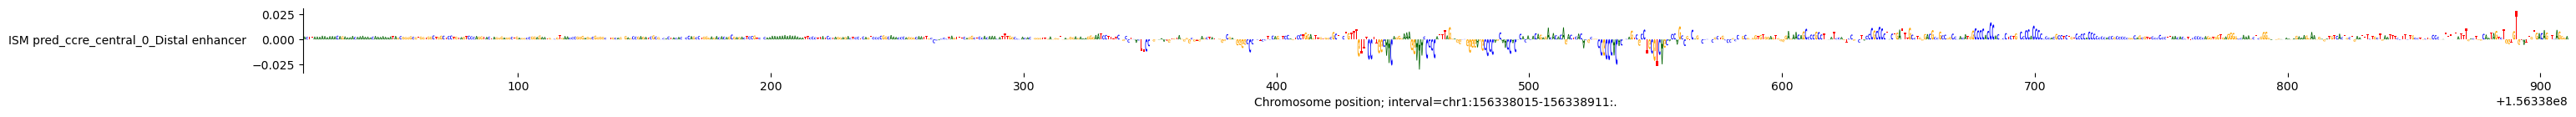

In [32]:
plot_components.plot(
    [
        plot_components.SeqLogo(
            scores=ism_result,
            scores_interval=ism_interval,
            ylabel=f'ISM {ccre_id}',
        )
    ],
    interval=ism_interval,
    fig_width=35,
)

plt.show()



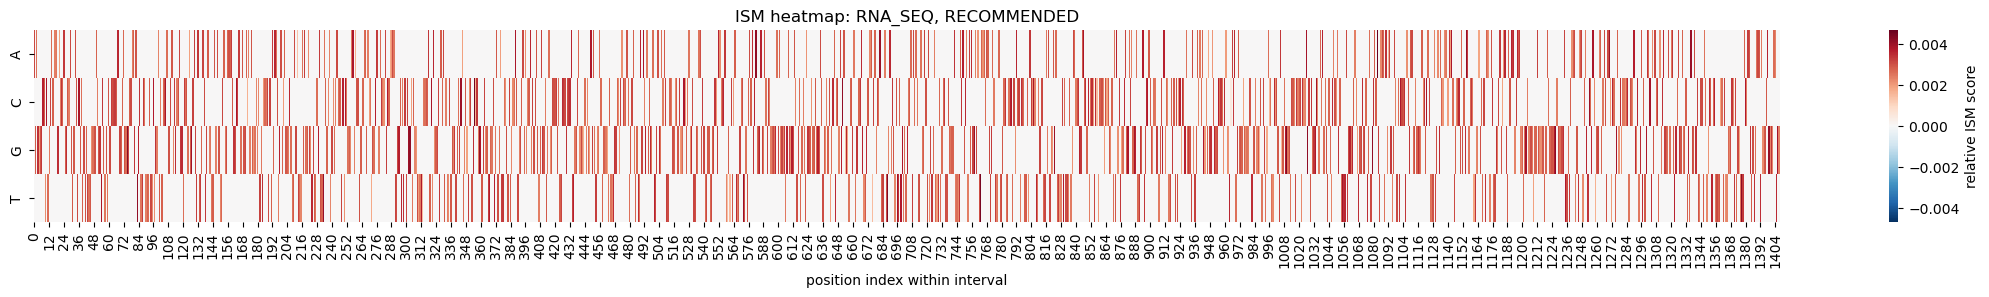

In [70]:
import seaborn as sns
import pandas as pd

hm = pd.DataFrame(ism_result.T, index=list('ACGT'))
vmax = np.nanmax(np.abs(hm.values)) or 1.0
plt.figure(figsize=(min(0.02 * hm.shape[1], 40), 2.5))
sns.heatmap(hm, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
            cbar_kws={'label': 'relative ISM score'})
plt.xlabel('position index within interval')
plt.title(f'ISM heatmap: {SCORE_COL}')
plt.show()

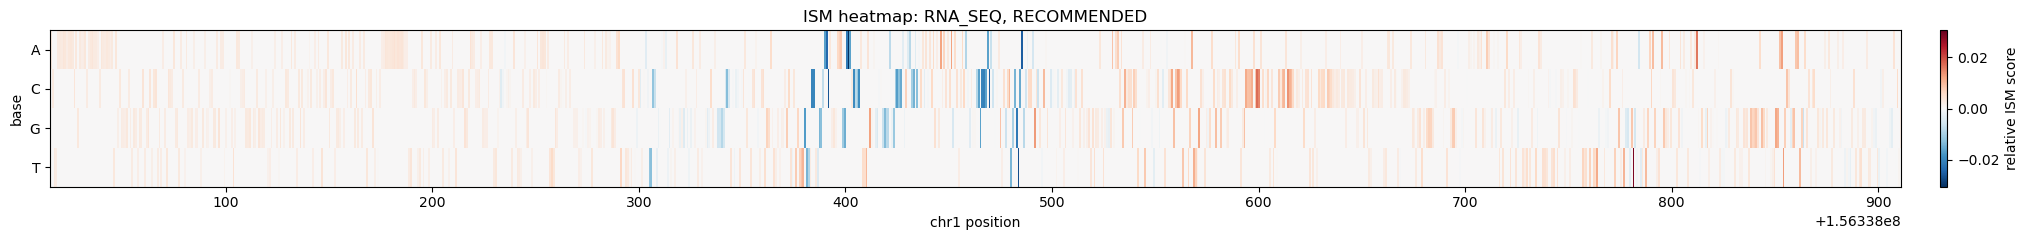

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Prefer all 4 bases visible in a heatmap
# (re-run ism.ism_matrix(..., multiply_by_sequence=False) if needed)
mat = ism_result  # (L, 4)

# Symmetric color scale around 0
vmax = np.nanmax(np.abs(mat)) or 1.0

fig, ax = plt.subplots(figsize=(min(0.02 * mat.shape[0], 40), 2.5))
im = ax.imshow(
    mat.T,                    # rows = bases, cols = genomic positions
    aspect='auto',
    interpolation='nearest',
    cmap='RdBu_r',
    vmin=-vmax,
    vmax=vmax,
    extent=[ism_interval.start, ism_interval.end, 3.5, -0.5],
)
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(list('ACGT'))
ax.set_xlabel(f'{ism_interval.chromosome} position')
ax.set_ylabel('base')
ax.set_title(f'ISM heatmap: {SCORE_COL}')
fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02, label='relative ISM score')
plt.tight_layout()
plt.show()

## Optional: all scorers

Build one ISM matrix per non-empty `RECOMMENDED` column in `ism_matrix_df`. Empty scorers are skipped.


In [ ]:
# Optional: build one ISM matrix per non-empty scorer column
score_cols = [c for c in ism_matrix_df.columns if c.endswith('RECOMMENDED')]
ism_by_scorer = {}
for col in score_cols:
    d = ism_matrix_df.dropna(subset=[col])
    d = d.loc[d.groupby('position')['alt'].transform('size') == 3]
    if d.empty:
        continue
    vs = [
        genome.Variant(
            chromosome=CHROM,
            position=int(r.position),
            reference_bases=r.ref,
            alternate_bases=r.alt,
        )
        for r in d.itertuples(index=False)
    ]
    ism_by_scorer[col] = ism.ism_matrix(
        d[col].astype(float).tolist(),
        variants=vs,
        interval=ism_interval,
        require_fully_filled=False,
    )

{k: v.shape for k, v in ism_by_scorer.items()}


NameError: name 'test' is not defined

# Rank variants

Keep the top 1% of variants **within each cCRE** by absolute `RNA_SEQ, RECOMMENDED` score (extreme positive or negative). This is per-cCRE, not a global ranking. Results go in `ism_df_top1`.


In [34]:
SCORE_COL = 'RNA_SEQ, RECOMMENDED'

# Top 1% by |quantile_score| within each output_type (extreme pos or neg)
q = 0.99

abs_score = ism_df[SCORE_COL].abs()
ism_thresh = abs_score.groupby(ism_df['ccre_id']).transform('quantile', q=q)
ism_df_top1 = ism_df[abs_score >= ism_thresh].copy().reset_index()

print(ism_df.groupby('ccre_id').size().rename('n_all').to_frame()
      .join(ism_df_top1.groupby('ccre_id').size().rename('n_top1%')))



                                        n_all  n_top1%
ccre_id                                               
pred_ccre_central_0_Distal enhancer      2688       27
pred_ccre_central_10_Proximal enhancer   2688       27
pred_ccre_central_11_Distal enhancer     1536       16
pred_ccre_central_12_Promoter            3072       31
pred_ccre_central_13_Proximal enhancer   6528       66
pred_ccre_central_14_Distal enhancer     3840       39
pred_ccre_central_15_Proximal enhancer   4224       43
pred_ccre_central_16_CA-CTCF             2304       24
pred_ccre_central_17_CA-H3K4me3          1536       16
pred_ccre_central_18_Distal enhancer     1536       16
pred_ccre_central_19_Distal enhancer     1536       16
pred_ccre_central_1_Distal enhancer      7296       73
pred_ccre_central_20_Distal enhancer     4608       47
pred_ccre_central_21_Distal enhancer     2688       27
pred_ccre_central_22_Distal enhancer     1920       20
pred_ccre_central_23_Proximal enhancer   1536       16
pred_ccre_

## Summary stats

Counts of remaining variants, unique positions, and unique position/alt combinations after the per-cCRE filter.


In [ ]:
## stats
print(f'scorer: {SCORE_COL}')
print(f'total number of variants after taking top 1% of variants per cCRE: {len(ism_df_top1.position)}')
print(f'total number of unique positions of variants after taking top 1% of variants per cCRE: {len(ism_df_top1.position.unique())}')
num_combos = ism_df_top1[['position', 'alt']].drop_duplicates().shape[0]
print(f'total number of unique variants after taking top 1% of variants per cCRE: {num_combos}')

ism_df_top1.head()

scorer: RNA_SEQ, RECOMMENDED
total number of variants after taking top 1% of variants per cCRE: 1050
total number of unique positions of variants after taking top 1% of variants per cCRE: 920
total number of unique variants after taking top 1% of variants per cCRE: 1050


## Save outputs

Write `outputs/ism_ccres_top1.tsv` (position, ref, alt, ccre_id) and `outputs/ism_ccres_top1_variant_strings.txt` (`chr1:pos:ref>alt`).


In [ ]:
ism_df_top1[['position', 'ref', 'alt', 'ccre_id']].to_csv('outputs/ism_ccres_top1.tsv', sep='\t', index=False)
CHROM = 'chr1'
with open('outputs/ism_ccres_top1_variant_strings.txt', 'w') as f:
    for idx, row in ism_df_top1.iterrows():
        pos = row.position
        ref = row.ref
        alt = row.alt
        variant = f'{CHROM}:{pos}:{ref}>{alt}'
        f.write(f'{variant}\n')